In [1]:
import os
import sys
import json

from pathlib import Path
from dotenv import load_dotenv


import matplotlib.pyplot as plt

path_proj = Path.cwd().parent
path_data = os.path.join(path_proj, "data")

load_dotenv()

sys.path.append(os.path.join(path_proj, "utils"))

%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Users\ander\AppData\Local\Programs\Python\Python314\Lib\shlex.py' for module 'shlex': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
  File "C:\Users\ander\AppData\Local\Programs\Python\Python314\Lib\importlib\__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1398, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1371, in _find_and_load
  File "<frozen im

In [2]:
neo4j_url = os.getenv("neo4jurl")
neo4j_user = os.getenv("noe4juser")
neo4j_password = os.getenv("neo4jpass")

In [3]:
from neo4j import GraphDatabase

with GraphDatabase.driver(neo4j_url, auth=(neo4j_user, neo4j_password)) as driver:
    driver.verify_connectivity()
    print("Successfully connected to Neo4j database")

Successfully connected to Neo4j database


In [4]:
driver = GraphDatabase.driver(neo4j_url, auth=(neo4j_user, neo4j_password))

with driver.session() as session:
    result = session.run("RETURN 1 AS number")
    record = result.single()
    print(f"Test query result: {record['number']}")

Test query result: 1


In [5]:
import pandas as pd
import ast

df_llm = pd.read_csv(os.path.join(path_data, "result_analysis.csv"))

df_llm["publication_date"] = pd.to_datetime(df_llm["publication_date"])
df_llm["embedding_signal"] = df_llm["embedding_signal"].apply(ast.literal_eval)

df_llm.head()

,url,title,publication_date,classification,score,signal,justification,evidence,embedding_signal
0,https://www.federalreserve.gov/newsevents/pres...,Federal Reserve issues FOMC statement,2026-01-28,mostly_dovish,-0.5,Low job gains and a stabilizing unemployment r...,The labor market is no longer described as str...,"Job gains have remained low, and the unemploym...","[-0.039459228515625, -0.01479339599609375, -0...."
1,https://www.federalreserve.gov/newsevents/pres...,Federal Reserve issues FOMC statement,2026-01-28,mostly_dovish,-0.5,Two FOMC members dissented in favor of an imme...,"The dissents provide a direct, though minority...","Stephen I. Miran and Christopher J. Waller, wh...","[0.010986328125, -0.03143310546875, -0.0175933..."
2,https://www.federalreserve.gov/newsevents/pres...,Federal Reserve issues FOMC statement,2026-01-28,neutral,0.0,The Committee retained a data-dependent approa...,The statement does not pre-commit to either cu...,the Committee will carefully assess incoming d...,"[-0.0172576904296875, -0.0224761962890625, -0...."
3,https://www.federalreserve.gov/newsevents/pres...,Federal Reserve issues FOMC statement,2026-01-28,neutral,0.0,The Committee emphasized two-sided risks aroun...,Attention to risks on both employment and infl...,The Committee is attentive to the risks to bot...,"[0.0009055137634277344, -0.0279388427734375, -..."
4,https://www.federalreserve.gov/newsevents/pres...,Federal Reserve issues FOMC statement,2026-01-28,neutral,0.0,The Committee stated it could adjust policy in...,This is a general contingency statement rather...,prepared to adjust the stance of monetary poli...,"[-0.006946563720703125, -0.0029315948486328125..."


In [6]:
df_llm.info()

<class 'pandas.DataFrame'>
RangeIndex: 10452 entries, 0 to 10451
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   url               10452 non-null  str           
 1   title             10452 non-null  str           
 2   publication_date  10452 non-null  datetime64[us]
 3   classification    10452 non-null  str           
 4   score             10452 non-null  float64       
 5   signal            10452 non-null  str           
 6   justification     10452 non-null  str           
 7   evidence          10452 non-null  str           
 8   embedding_signal  10452 non-null  object        
dtypes: datetime64[us](1), float64(1), object(1), str(6)
memory usage: 735.0+ KB


In [ ]:
for ind, row in df_llm.iterrows():
    query = """
       MERGE (p:Publication {url: $url})
       SET
            p.title = $title,
            p.publication_date = $publication_date
    """

    records, summary, keys = driver.execute_query(
        query,
        parameters_={
            "url": row["url"],
            "title": row["title"],
            "publication_date": row["publication_date"].to_pydatetime(),
        }
    )

    # query = """
    #     MERGE (d:Date {date: $publication_date})
    #     """
    # records, summary, keys = driver.execute_query(
    #     query,
    #     parameters_={
    #         "publication_date": row["publication_date"].to_pydatetime(),
    #     }
    # )

    # query = """
    #     MATCH (p:Publication {url: $url})
    #     MATCH (d:Date {date: $publication_date})
    #     MERGE (p)-[:PUBLISHED_ON]->(d)
    # """
    # records, summary, keys = driver.execute_query(
    #     query,
    #     parameters_={
    #         "url": row["url"],
    #         "publication_date": row["publication_date"].to_pydatetime(),
    #     }
    # )

    query = """
        MERGE (s:Signal {text: $signal,
                         url: $url})
        SET s.classification = $classification,
            s.score = $score,
            s.justification = $justification,
            s.evidence = $evidence,
            s.embedding_signal = $embedding_signal,
            s.date = $publication_date
    """
    records, summary, keys = driver.execute_query(
        query,
        parameters_={
            "signal": row["signal"],
            "url": row["url"],
            "classification": row["classification"],
            "score": row["score"],
            "justification": row["justification"],
            "evidence": row["evidence"],
            "embedding_signal": row["embedding_signal"],
            "publication_date": row["publication_date"].to_pydatetime(),
        }
    )

    query = """
        MATCH (p:Publication {url: $url})
        MATCH (s:Signal {text: $signal,
                         url: $url})
        MERGE (p)-[:HAS_SIGNAL]->(s)
    """
    records, summary, keys = driver.execute_query(
        query,
        parameters_={
            "url": row["url"],
            "signal": row["signal"],
        }
    )
    print(f"Processed record {ind} with URL: {row['url']}")


Processed record 0 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 1 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 2 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 3 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 4 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 5 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 6 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 7 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 8 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 9 with URL: https://

In [ ]:
import json
from pathlib import Path

path_proj = Path.cwd().parent
path_data = path_proj / "data"

with open(path_data / "links_text.txt", "r", encoding="utf-8") as file:
    links_text = json.load(file)

links_text[0]

{'url': 'https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm',
 'title': 'Federal Reserve issues FOMC statement',
 'text': "\ufeff\nFederal Reserve Board - Federal Reserve issues FOMC statement\nSkip to main content\nAn official website of the United States Government\nHere's how you know\nOfficial websites use .gov\nA\n.gov\nwebsite belongs to an official government organization in the United States.\nSecure .gov websites use HTTPS\nA\nlock\n(\nLock\nLocked padlock icon\n) or\nhttps://\nmeans you've safely connected to the .gov website. Share sensitive information only on official, secure websites.\nBack to Home\nBoard of Governors of the Federal Reserve System\nStay Connected\nFederal Reserve Facebook Page\nFederal Reserve Instagram Page\nFederal Reserve YouTube Page\nFederal Reserve Flickr Page\nFederal Reserve LinkedIn Page\nFederal Reserve Threads Page\nFederal Reserve X Page\nFederal Reserve Bluesky Page\nSubscribe to RSS\nSubscribe to Email\nRecent Post

In [ ]:
len(links_text)

1310

In [ ]:
target_title = "Federal Reserve issues FOMC statement"

dates_fomc_statement = sorted(
    {
        item.get("publication_date")
        for item in links_text
        if item.get("title") == target_title and item.get("publication_date")
    }
)

dates_fomc_statement

['2015-01-28',
 '2015-03-18',
 '2015-04-29',
 '2015-06-17',
 '2015-07-29',
 '2015-09-17',
 '2015-10-28',
 '2015-12-16',
 '2016-01-27',
 '2016-03-16',
 '2016-04-27',
 '2016-06-15',
 '2016-07-27',
 '2016-09-21',
 '2016-11-02',
 '2016-12-14',
 '2017-02-01',
 '2017-03-15',
 '2017-05-03',
 '2017-06-14',
 '2017-07-26',
 '2017-09-20',
 '2017-11-01',
 '2017-12-13',
 '2018-01-31',
 '2018-03-21',
 '2018-05-02',
 '2018-06-13',
 '2018-08-01',
 '2018-09-26',
 '2018-11-08',
 '2018-12-19',
 '2019-01-30',
 '2019-03-20',
 '2019-05-01',
 '2019-06-19',
 '2019-07-31',
 '2019-09-18',
 '2019-10-30',
 '2019-12-11',
 '2020-01-29',
 '2020-03-03',
 '2020-03-15',
 '2020-03-23',
 '2020-04-29',
 '2020-06-10',
 '2020-07-29',
 '2020-09-16',
 '2020-11-05',
 '2020-12-16',
 '2021-01-27',
 '2021-03-17',
 '2021-04-28',
 '2021-06-16',
 '2021-07-28',
 '2021-09-22',
 '2021-11-03',
 '2021-12-15',
 '2022-01-26',
 '2022-03-16',
 '2022-05-04',
 '2022-06-15',
 '2022-07-27',
 '2022-09-21',
 '2022-11-02',
 '2022-12-14',
 '2023-02-

In [ ]:
from datetime import datetime

start_date = dates_fomc_statement[0]
end_date = dates_fomc_statement[1]

print(start_date)

2015-01-28


In [ ]:
FRED_key = os.getenv('api_key_FRED')
api_key = FRED_key

print(api_key)

72f7955268d6a65a486d6ca126771837


In [ ]:
import requests

def get_fred_data(id_data: str) -> pd.DataFrame:
    url = f'https://api.stlouisfed.org/fred/series/observations?series_id={id_data}&api_key={api_key}&file_type=json'
    response = requests.get(url)

    # Check to make sure the request was successful
    if response.status_code != 200:
        raise Exception('Failed to get data:', response.status_code)
    else:
        # Convert the response to a dictionary
        data = response.json()

        # Extract the 'observations' field from the data
        observations = data['observations']

        # Create a pandas DataFrame from the observations
        df = pd.DataFrame(observations)

        return df

# df_upper = get_fred_data('DFEDTARL')
# df_upper.head(5)

In [ ]:
def get_diff_federal_funds() -> pd.DataFrame:
    df_lower = get_fred_data('DFEDTARL')[["date", "value"]].copy()
    df_upper = get_fred_data('DFEDTARU')[["date", "value"]].copy()

    df_lower["date"] = pd.to_datetime(df_lower["date"])
    df_lower["value"] = df_lower["value"].astype(float)
    df_upper["date"] = pd.to_datetime(df_upper["date"])
    df_upper["value"] = df_upper["value"].astype(float)
    df_lower = df_lower.rename(columns={"value": "lower_value"})
    df_upper = df_upper.rename(columns={"value": "upper_value"})

    return df_lower.merge(df_upper, on="date", how="inner")

In [ ]:
df_fred = get_diff_federal_funds()

df_fred.head(5)

,date,lower_value,upper_value
0,2008-12-16,0.0,0.25
1,2008-12-17,0.0,0.25
2,2008-12-18,0.0,0.25
3,2008-12-19,0.0,0.25
4,2008-12-20,0.0,0.25


In [ ]:
statement_dates = pd.to_datetime(dates_fomc_statement).normalize()
df_fred_statement_dates = df_fred[
    df_fred["date"].dt.normalize().isin(statement_dates)
].copy()
df_fred_statement_dates = df_fred_statement_dates.sort_values("date")
# df_fred_statement_dates["lower_rate_change"] = df_fred_statement_dates["lower_value"].diff()
df_fred_statement_dates["upper_rate_change"] = df_fred_statement_dates["upper_value"].diff().fillna(0)
df_fred_statement_dates

,date,lower_value,upper_value,upper_rate_change
2234,2015-01-28,0.0,0.25,0.0
2283,2015-03-18,0.0,0.25,0.0
2325,2015-04-29,0.0,0.25,0.0
2374,2015-06-17,0.0,0.25,0.0
2416,2015-07-29,0.0,0.25,0.0
...,...,...,...,...
6301,2026-03-18,3.5,3.75,0.0
6343,2026-04-29,3.5,3.75,0.0
6392,2026-06-17,3.5,3.75,0.0
6434,2026-07-29,3.5,3.75,0.0


# Rodando analises no grafo

In [ ]:
from graph_utils import drop_projection

In [ ]:
start_date = dates_fomc_statement[0]
end_date = dates_fomc_statement[1]

In [ ]:
def drop_connections_similar():
    query = """
    MATCH ()-[r:SIMILAR_TO]-()
    DELETE r
    RETURN count(r) AS removed_relationships
    """
    records, summary, keys = driver.execute_query(query)
    print(f"{records[0]['removed_relationships']} SIMILAR_TO relationships removed")

In [ ]:
def create_similar_connections(
        start_date,
        end_date,
        similarity_cutoff=0.8
        ):
    drop_connections_similar()
    drop_projection('signal-cypher')

    query = """
    MATCH (source:Signal)
    WHERE source.embedding_signal IS NOT NULL
        AND source.date >= localdatetime($start_date)
        AND source.date < localdatetime($end_date)
    WITH gds.graph.project(
        'signal-cypher',
        source,
        null,
        {
            sourceNodeProperties: source {.embedding_signal},
            targetNodeProperties: null
        }
    ) as g
    RETURN g.graphName AS graph, g.nodeCount AS nodes, g.relationshipCount AS rels
    """
    records, summary, keys = driver.execute_query(query,
                                                parameters_= {
                                                    "start_date": start_date,
                                                    "end_date": end_date,
                                                    }
    )


    print(f"Created graph 'signal-cypher' with {records[0]['nodes']}")


    query = """
    CALL gds.knn.stream(
        'signal-cypher',
        {
            nodeProperties: [
                {embedding_signal: 'COSINE'}
            ],
            similarityCutoff: $similarity_cutoff,
            topK: 50,
            randomSeed: 42,
            concurrency: 1
        }
    )
    YIELD node1, node2, similarity
    WITH
        gds.util.asNode(node1) AS n1,
        gds.util.asNode(node2) AS n2,
        similarity
    WHERE elementId(n1) < elementId(n2)
    MERGE (n1)-[r:SIMILAR_TO]-(n2)
    SET r.score_similarity = similarity
    RETURN count(r) AS total_score_relationships
    """
    records, summary, keys = driver.execute_query(
        query,
        parameters_={"similarity_cutoff": similarity_cutoff},
    )
    print(f"Criadas {records[0]['total_score_relationships']} relationships SIMILAR_TO")

create_similar_connections(start_date, end_date)

3594 SIMILAR_TO relationships removed
Projection 'signal-cypher' does not exist
Created graph 'signal-cypher' with 63
Criadas 79 relationships SIMILAR_TO


In [ ]:
def run_wcc(start_date, end_date):
    graph_name = "signal-wcc"
    drop_projection(graph_name)

    query = """
    MATCH (source:Signal)
    WHERE source.embedding_signal IS NOT NULL
        AND source.date >= localdatetime($start_date)
        AND source.date < localdatetime($end_date)

    OPTIONAL MATCH (source)-[r:SIMILAR_TO]-(target:Signal)
    WHERE target.embedding_signal IS NOT NULL
        AND target.date >= localdatetime($start_date)
        AND target.date < localdatetime($end_date)

    WITH gds.graph.project(
        'signal-wcc',
        source,
        target,
        {
            sourceNodeProperties: source {.embedding_signal, .score},
            targetNodeProperties: target {.embedding_signal, .score},
            relationshipProperties: r {.score_similarity}
        },
        {undirectedRelationshipTypes: ['*']}
    ) AS g
    RETURN g.graphName AS graph, g.nodeCount AS nodes, g.relationshipCount AS rels
    """
    records, summary, keys = driver.execute_query(
        query,
        parameters_={
            "start_date": start_date,
            "end_date": end_date,
        },
    )
    projection = records[0]
    print(
        f"Projection '{projection['graph']}': {projection['nodes']} nodes, "
        f"{projection['rels']} relationships"
    )

    query = """
    CALL gds.wcc.stream('signal-wcc')
    YIELD nodeId, componentId
    RETURN count(DISTINCT componentId) AS number_of_communities
    """
    records, summary, keys = driver.execute_query(query)
    number_of_communities = records[0]["number_of_communities"]
    print(f"{number_of_communities} communities")
    return number_of_communities

number_of_communities = run_wcc(start_date, end_date)

Projection 'signal-wcc' does not exist
Projection 'signal-wcc': 63 nodes, 316 relationships
20 communities


In [ ]:
def refine_similarity_cutoff(
    start_date,
    end_date,
    initial_cutoff=0.8,
    step=0.01,
    min_cutoff=0.1,
):
    similarity_cutoff = initial_cutoff

    while similarity_cutoff >= min_cutoff:
        create_similar_connections(start_date, end_date, similarity_cutoff)
        number_of_communities = run_wcc(start_date, end_date)

        if number_of_communities == 1:
            print(f"Single community reached with cutoff {similarity_cutoff:.2f}")
            return similarity_cutoff

        similarity_cutoff = round(similarity_cutoff - step, 10)

    raise RuntimeError(
        "A single community was not reached before the minimum cutoff."
    )

best_similarity_cutoff = refine_similarity_cutoff(start_date, end_date)

158 SIMILAR_TO relationships removed


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 63


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Criadas 79 relationships SIMILAR_TO
Projection 'signal-wcc' removed


...

Criadas 494 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 63 nodes, 1976 relationships
2 communities
988 SIMILAR_TO relationships removed


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 63


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Criadas 605 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 63 nodes, 2420 relationships
1 communities
Single community reached with cutoff 0.71


In [ ]:
def run_leiden_communities(graph_name="signal-wcc"):
    query = """
    CALL gds.leiden.stream(
        $graph_name,
        {
            relationshipWeightProperty: 'score_similarity',
            randomSeed: 42,
            concurrency: 1
        }
    )
    YIELD nodeId, communityId
    RETURN
        nodeId,
        communityId,
        gds.util.asNode(nodeId).score AS node_score
    ORDER BY communityId
    """

    records, summary, keys = driver.execute_query(
        query,
        parameters_={"graph_name": graph_name},
    )
    return pd.DataFrame([record.data() for record in records])


leiden_results = run_leiden_communities()
number_of_leiden_communities = leiden_results["communityId"].nunique()
print(f"Número de comunidades Leiden: {number_of_leiden_communities}")
leiden_results.head()

Número de comunidades Leiden: 5


,nodeId,communityId,node_score
0,10801,1,-1.0
1,4434,1,-0.5
2,4442,1,0.5
3,4445,1,-1.0
4,4450,1,-0.5


In [ ]:
def run_betweenness_centrality():
    query = """
    CALL gds.betweenness.stream(
        'signal-wcc',
        {relationshipWeightProperty: 'score_similarity'}
    )
    YIELD nodeId, score
    RETURN
        nodeId,
        score AS betweenness_centrality,
        gds.util.asNode(nodeId).score AS node_score
    ORDER BY betweenness_centrality DESC
    """
    records, summary, keys = driver.execute_query(query)
    return pd.DataFrame([record.data() for record in records])

betweenness_results = run_betweenness_centrality()
betweenness_results

,nodeId,betweenness_centrality,node_score
0,10788,212.0,0.5
1,10767,199.0,-1.0
2,10779,178.0,-1.0
3,4454,176.0,0.0
4,10798,120.0,0.0
...,...,...,...
58,10782,0.0,-0.5
59,10789,0.0,0.5
60,10793,0.0,-1.0
61,10797,0.0,-0.5


In [ ]:
def run_weighted_degree_centrality():
    query = """
    CALL gds.degree.stream(
        'signal-wcc',
        {relationshipWeightProperty: 'score_similarity',
         orientation: 'UNDIRECTED'}
    )
    YIELD nodeId, score
    RETURN nodeId, score AS degree_centrality
    ORDER BY degree_centrality DESC
    """
    records, summary, keys = driver.execute_query(query)
    return pd.DataFrame([record.data() for record in records])

degree_centrality_results = run_weighted_degree_centrality()
degree_centrality_results

,nodeId,degree_centrality
0,4446,133.343227
1,10801,125.590070
2,4433,117.320805
3,4436,115.810615
4,4454,111.714942
...,...,...
58,10783,9.665931
59,10798,8.975325
60,10782,6.654887
61,10799,6.078727


In [ ]:
def run_weighted_pagerank():
    query = """
    CALL gds.pageRank.stream(
        'signal-wcc',
        {relationshipWeightProperty: 'score_similarity'}
    )
    YIELD nodeId, score
    RETURN nodeId, score AS pagerank_centrality
    ORDER BY pagerank_centrality DESC
    """
    records, summary, keys = driver.execute_query(query)
    return pd.DataFrame([record.data() for record in records])

pagerank_results = run_weighted_pagerank()
pagerank_results

,nodeId,pagerank_centrality
0,4446,1.904620
1,10801,1.820912
2,4454,1.678443
3,4433,1.671143
4,4436,1.659570
...,...,...
58,4437,0.450137
59,10771,0.398110
60,10783,0.375931
61,10789,0.352396


In [ ]:
def calculate_period_sentiment_score(start_date, end_date):
    degree_centrality_results = run_weighted_degree_centrality()
    pagerank_results = run_weighted_pagerank()
    centrality_results = run_betweenness_centrality().merge(
        degree_centrality_results,
        on="nodeId",
        how="left",
    ).merge(
        pagerank_results,
        on="nodeId",
        how="left",
    )
    valid_scores = centrality_results.dropna(
        subset=[
            "node_score",
            "betweenness_centrality",
            "degree_centrality",
            "pagerank_centrality",
        ]
    )

    if valid_scores.empty:
        raise ValueError("No nodes with centrality and sentiment scores are available.")

    graph_query = """
    CALL gds.graph.list()
    YIELD graphName, nodeCount, relationshipCount
    WHERE graphName = 'signal-wcc'
    RETURN nodeCount, relationshipCount
    """
    records, summary, keys = driver.execute_query(graph_query)
    graph_metrics = records[0]

    betweenness_weighted_sentiment = (
        valid_scores["node_score"] * valid_scores["betweenness_centrality"]
    ).sum() / valid_scores["betweenness_centrality"].sum()

    degree_weighted_sentiment = (
        valid_scores["node_score"] * valid_scores["degree_centrality"]
    ).sum() / valid_scores["degree_centrality"].sum()

    pagerank_weighted_sentiment = (
        valid_scores["node_score"] * valid_scores["pagerank_centrality"]
    ).sum() / valid_scores["pagerank_centrality"].sum()

    simple_mean_sentiment = valid_scores["node_score"].mean()

    leiden_results = run_leiden_communities()
    community_scores = (
        leiden_results.groupby("communityId", as_index=False)
        .agg(
            community_sentiment=("node_score", "mean"),
            community_size=("nodeId", "size"),
        )
    )
    leiden_equal_weight_sentiment = community_scores["community_sentiment"].mean()
    largest_community_index = community_scores["community_size"].idxmax()
    largest_leiden_community_size = community_scores.loc[
        largest_community_index, "community_size"
    ]
    largest_community_sentiment = community_scores.loc[
        largest_community_index, "community_sentiment"
    ]
    largest_community_size_share = (
        largest_leiden_community_size / community_scores["community_size"].sum()
    )
    largest_community_size_weighted_sentiment = (
        largest_community_sentiment * largest_community_size_share
    )

    community_pagerank_scores = (
        leiden_results.merge(pagerank_results, on="nodeId", how="inner")
        .assign(
            pagerank_weighted_score=lambda data: (
                data["node_score"] * data["pagerank_centrality"]
            )
        )
        .groupby("communityId", as_index=False)
        .agg(
            pagerank_weighted_score=("pagerank_weighted_score", "sum"),
            pagerank_total=("pagerank_centrality", "sum"),
        )
    )
    community_pagerank_scores["community_pagerank_sentiment"] = (
        community_pagerank_scores["pagerank_weighted_score"]
        / community_pagerank_scores["pagerank_total"]
    )
    community_pagerank_weighted_sentiment = (
        community_pagerank_scores["community_pagerank_sentiment"].mean()
    )

    return pd.DataFrame(
        [{
            "start_date": start_date,
            "end_date": end_date,
            "node_count": graph_metrics["nodeCount"],
            "relationship_count": graph_metrics["relationshipCount"],
            "number_of_leiden_communities": len(community_scores),
            "largest_leiden_community_size": largest_leiden_community_size,
            "leiden_equal_weight_sentiment": leiden_equal_weight_sentiment,
            "largest_community_size_weighted_sentiment": (
                largest_community_size_weighted_sentiment
            ),
            "simple_mean_sentiment": simple_mean_sentiment,
            "betweenness_weighted_sentiment": betweenness_weighted_sentiment,
            "degree_weighted_sentiment": degree_weighted_sentiment,
            "pagerank_weighted_sentiment": pagerank_weighted_sentiment,
            "community_pagerank_weighted_sentiment": (
                community_pagerank_weighted_sentiment
            ),
        }]
    )

period_sentiment_scores = calculate_period_sentiment_score(start_date, end_date)
period_sentiment_scores

,start_date,end_date,node_count,relationship_count,number_of_leiden_communities,largest_leiden_community_size,leiden_equal_weight_sentiment,largest_community_size_weighted_sentiment,simple_mean_sentiment,betweenness_weighted_sentiment,degree_weighted_sentiment,pagerank_weighted_sentiment,community_pagerank_weighted_sentiment
0,2015-01-28,2015-03-18,93,3744,4,28,0.436071,0.139785,0.44086,0.541388,0.51408,0.503127,0.486819


In [ ]:
def analyze_all_statement_periods(dates_fomc_statement):
    period_scores = []

    for start_date, end_date in zip(
        dates_fomc_statement[:-1],
        dates_fomc_statement[1:],
    ):
        print(f"Analyzing {start_date} to {end_date}")
        similarity_cutoff = refine_similarity_cutoff(start_date, end_date)
        period_score = calculate_period_sentiment_score(start_date, end_date)
        period_score["similarity_cutoff"] = similarity_cutoff
        period_scores.append(period_score)

    return pd.concat(period_scores, ignore_index=True)

all_period_sentiment_scores = analyze_all_statement_periods(dates_fomc_statement)
all_period_sentiment_scores

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Analyzing 2015-01-28 to 2015-03-18
2808 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 63


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'
Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassifi

Criadas 79 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 63 nodes, 316 relationships
20 communities
158 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 63


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'
Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassifi

...

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'
Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassifi

Criadas 198 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 63 nodes, 792 relationships
6 communities
396 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 63


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'
Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassifi

Criadas 253 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 63 nodes, 1012 relationships
4 communities
506 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 63


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


In [ ]:
all_period_sentiment_scores

,start_date,end_date,node_count,relationship_count,number_of_leiden_communities,largest_leiden_community_size,leiden_equal_weight_sentiment,community_sentiment_polarization,simple_mean_sentiment,structural_sentiment,betweenness_weighted_sentiment,degree_weighted_sentiment,pagerank_weighted_sentiment,community_pagerank_weighted_sentiment,similarity_cutoff
0,2015-01-28,2015-03-18,63,2420,5,26,-0.327127,0.236163,-0.309524,-0.478323,-0.342177,-0.423077,-0.388588,-0.370562,0.71
1,2015-03-18,2015-04-29,114,6712,5,32,-0.269858,0.169922,-0.271930,-0.365045,-0.308037,-0.325871,-0.311888,-0.287589,0.72
2,2015-04-29,2015-06-17,73,2236,5,27,-0.226465,0.236266,-0.267123,-0.330145,-0.306474,-0.308506,-0.299071,-0.218550,0.73
3,2015-06-17,2015-07-29,106,5072,6,25,-0.260305,0.278015,-0.297170,-0.427969,-0.291188,-0.401612,-0.366963,-0.287993,0.74
4,2015-07-29,2015-09-17,48,1556,5,12,-0.212381,0.339539,-0.270833,-0.353086,-0.303870,-0.355758,-0.325187,-0.241466,0.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,2026-01-28,2026-03-18,143,5304,5,42,0.095971,0.225891,0.048951,0.029259,0.033708,0.041395,0.042228,0.098119,0.74
91,2026-03-18,2026-04-29,140,11680,3,60,0.195038,0.255494,0.246429,0.294334,0.202550,0.289401,0.273228,0.195192,0.69
92,2026-04-29,2026-06-17,110,8136,3,46,0.197947,0.149827,0.218182,0.285048,0.231968,0.269910,0.257003,0.216089,0.69
93,2026-06-17,2026-07-29,115,5868,4,46,0.314849,0.114349,0.365217,0.452619,0.382669,0.449213,0.426557,0.365253,0.72


In [ ]:
output_file = path_data / "period_sentiment_scores.csv"
all_period_sentiment_scores.to_csv(output_file, index=False)
print(f"Saved results to {output_file}")

Saved results to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\data\period_sentiment_scores.csv


In [ ]:
import pandas as pd

all_period_sentiment_scores = pd.read_csv(
    Path(path_data) / "period_sentiment_scores.csv",
    parse_dates=["start_date", "end_date"],
)
all_period_sentiment_scores.head()

,start_date,end_date,node_count,relationship_count,number_of_leiden_communities,largest_leiden_community_size,leiden_equal_weight_sentiment,community_sentiment_polarization,simple_mean_sentiment,structural_sentiment,betweenness_weighted_sentiment,degree_weighted_sentiment,pagerank_weighted_sentiment,community_pagerank_weighted_sentiment,similarity_cutoff
0,2015-01-28,2015-03-18,63,2420,5,26,-0.327127,0.236163,-0.309524,-0.478323,-0.342177,-0.423077,-0.388588,-0.370562,0.71
1,2015-03-18,2015-04-29,114,6712,5,32,-0.269858,0.169922,-0.271930,-0.365045,-0.308037,-0.325871,-0.311888,-0.287589,0.72
2,2015-04-29,2015-06-17,73,2236,5,27,-0.226465,0.236266,-0.267123,-0.330145,-0.306474,-0.308506,-0.299071,-0.218550,0.73
3,2015-06-17,2015-07-29,106,5072,6,25,-0.260305,0.278015,-0.297170,-0.427969,-0.291188,-0.401612,-0.366963,-0.287993,0.74
4,2015-07-29,2015-09-17,48,1556,5,12,-0.212381,0.339539,-0.270833,-0.353086,-0.303870,-0.355758,-0.325187,-0.241466,0.72


Figure saved to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\TCC_latex\figuras\node_count_by_fomc_period.png


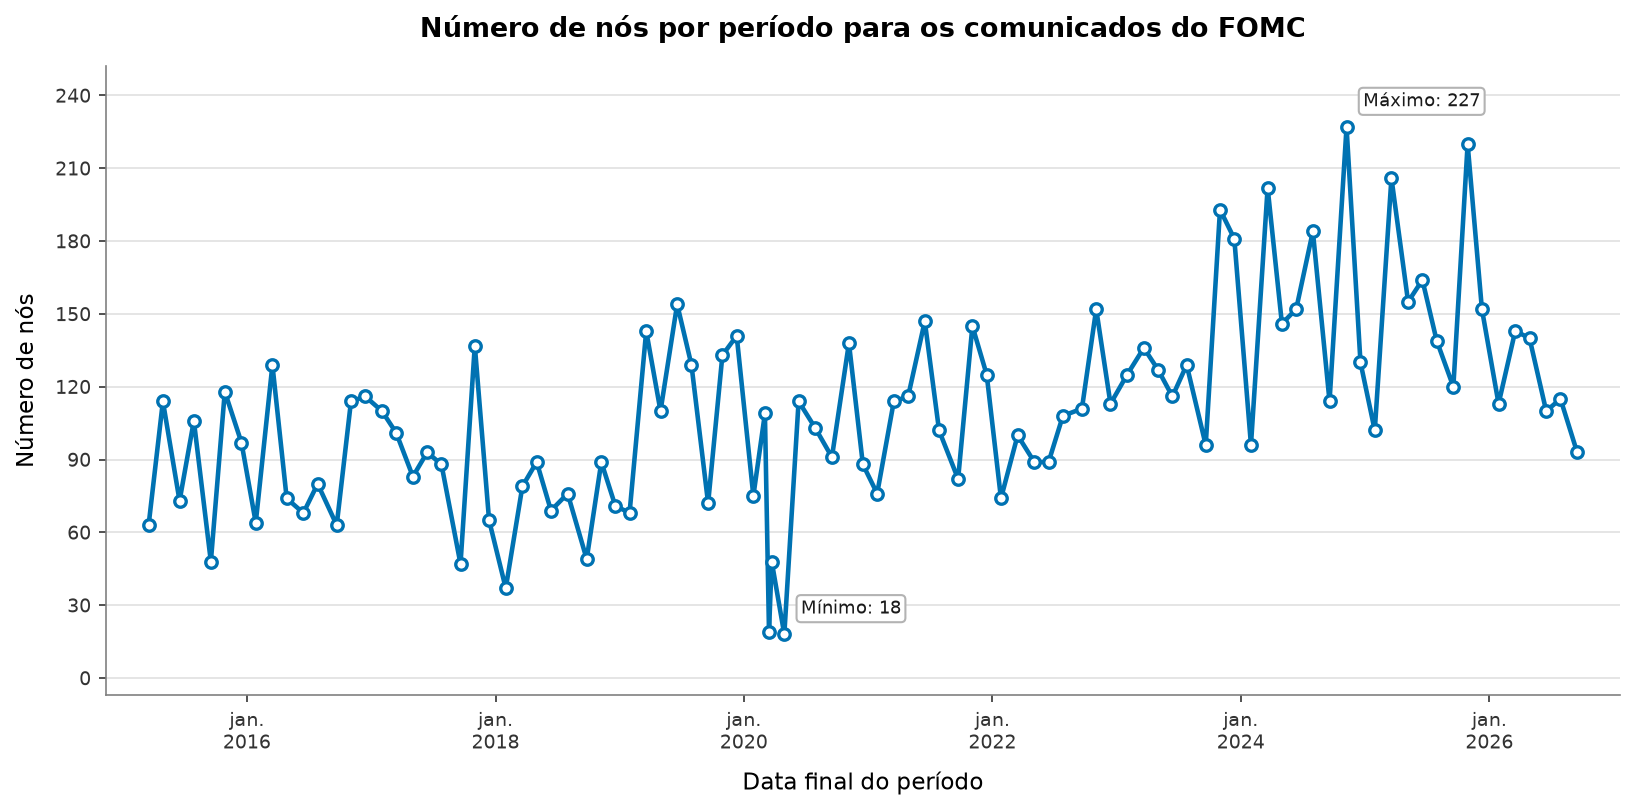

In [ ]:
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, MaxNLocator

node_count_by_period = all_period_sentiment_scores.copy()
node_count_by_period['end_date'] = pd.to_datetime(node_count_by_period['end_date'])
node_count_by_period = node_count_by_period.sort_values('end_date')

month_abbreviations = [
    'jan.', 'fev.', 'mar.', 'abr.', 'maio', 'jun.',
    'jul.', 'ago.', 'set.', 'out.', 'nov.', 'dez.',
]

def format_date_pt_br(value, position):
    date = mdates.num2date(value)
    return f'{month_abbreviations[date.month - 1]}\n{date.year}'

fig, ax = plt.subplots(figsize=(11, 5.5), dpi=150)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(
    node_count_by_period['end_date'],
    node_count_by_period['node_count'],
    color='#0072B2',
    linewidth=2.2,
    marker='o',
    markersize=5.5,
    markerfacecolor='white',
    markeredgewidth=1.6,
    zorder=3,
)

for index, label in [
    (node_count_by_period['node_count'].idxmin(), 'Mínimo'),
    (node_count_by_period['node_count'].idxmax(), 'Máximo'),
]:
    period = node_count_by_period.loc[index]
    ax.annotate(
        f"{label}: {period['node_count']:.0f}",
        (period['end_date'], period['node_count']),
        xytext=(8, 10),
        textcoords='offset points',
        fontsize=8.5,
        color='#1A1A1A',
        bbox={'boxstyle': 'round,pad=0.25', 'facecolor': 'white', 'edgecolor': '#B3B3B3'},
    )

ax.set_title('Número de nós por período para os comunicados do FOMC', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Data final do período', fontsize=11, labelpad=8)
ax.set_ylabel('Número de nós', fontsize=11, labelpad=8)
ax.xaxis.set_major_formatter(FuncFormatter(format_date_pt_br))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis='y', color='#D9D9D9', linewidth=0.8, alpha=0.8, zorder=0)
ax.grid(axis='x', visible=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#808080')
ax.spines['bottom'].set_color('#808080')
ax.tick_params(axis='both', labelsize=9, colors='#333333')
ax.margins(x=0.03, y=0.12)

plt.tight_layout()
figure_path = path_proj / 'TCC_latex' / 'figuras' / 'node_count_by_fomc_period.png'
fig.savefig(figure_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Figure saved to {figure_path}')
plt.show()

Figure saved to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\TCC_latex\figuras\sentiment_centrality_by_fomc_period.png


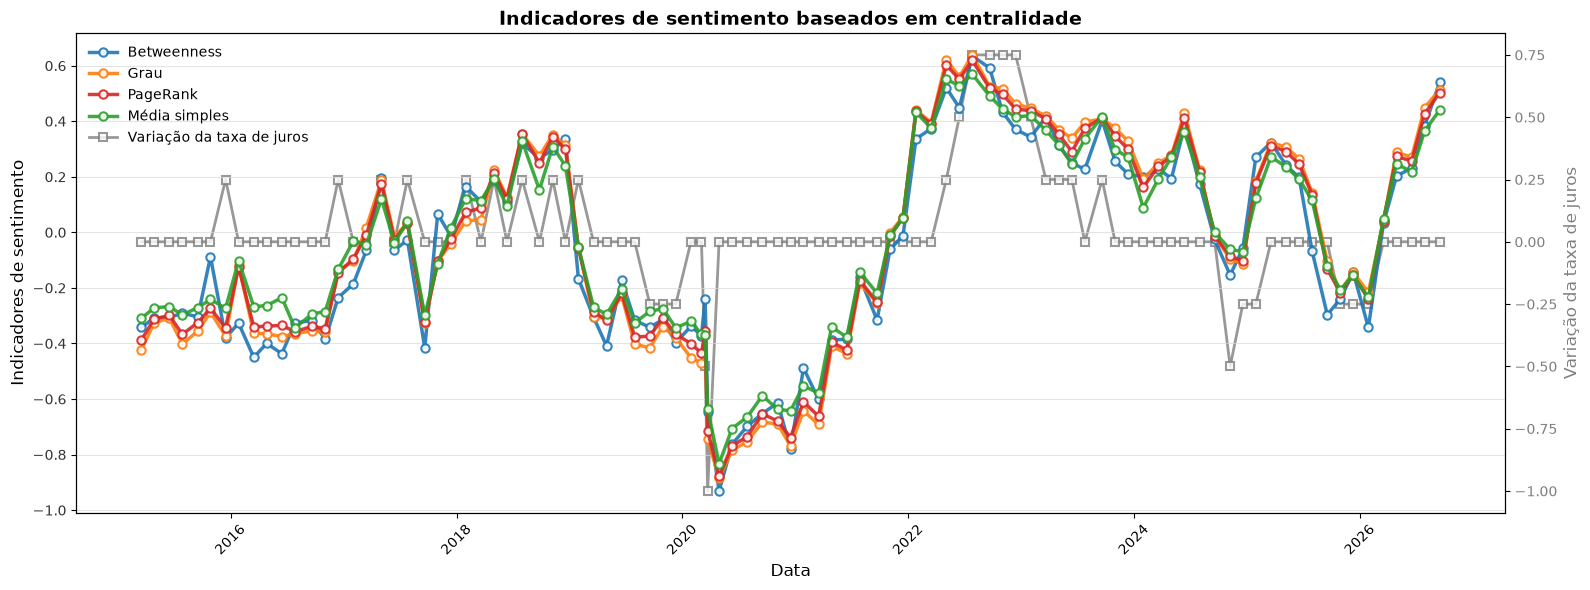

Figure saved to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\TCC_latex\figuras\sentiment_community_by_fomc_period.png


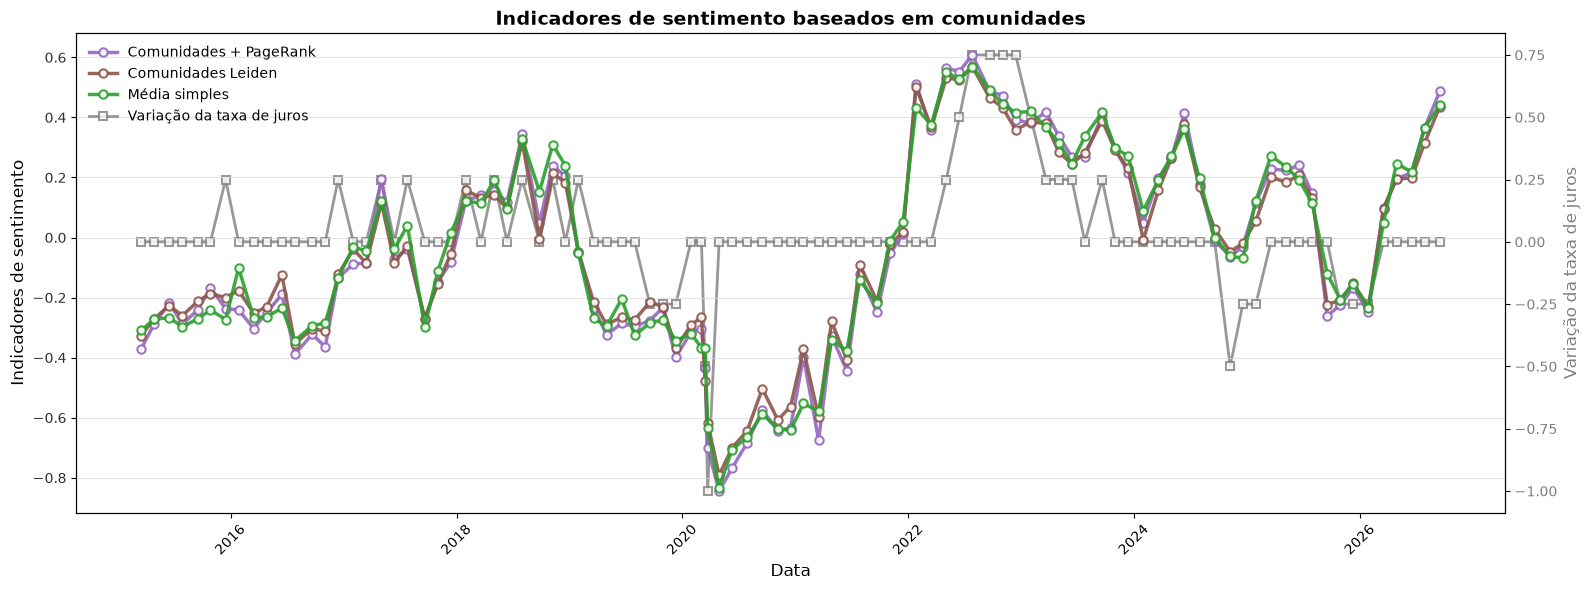

In [ ]:
def analyze_sentiment_evolution(all_period_sentiment_scores, federal_funds_rate):
    """Analyze centrality and community sentiment indicators over time."""

    all_period_sentiment_scores = all_period_sentiment_scores.copy()
    all_period_sentiment_scores['end_date'] = pd.to_datetime(
        all_period_sentiment_scores['end_date']
    )

    sentiment_evolution = all_period_sentiment_scores.merge(
        federal_funds_rate,
        left_on='end_date',
        right_on='date',
        how='left'
    )

    sentiment_labels = {
        "betweenness_weighted_sentiment": "Betweenness",
        "degree_weighted_sentiment": "Grau",
        "pagerank_weighted_sentiment": "PageRank",
        "community_pagerank_weighted_sentiment": "Comunidades + PageRank",
        "leiden_equal_weight_sentiment": "Comunidades Leiden",
        "largest_community_size_weighted_sentiment": (
            "Maior comunidade ponderada pelo tamanho"
        ),
        "simple_mean_sentiment": "Média simples",
    }

    centrality_columns = [
        "betweenness_weighted_sentiment",
        "degree_weighted_sentiment",
        "pagerank_weighted_sentiment",
        "simple_mean_sentiment",
    ]
    community_columns = [
        "community_pagerank_weighted_sentiment",
        "leiden_equal_weight_sentiment",
        "largest_community_size_weighted_sentiment",
        "simple_mean_sentiment",
    ]

    def plot_sentiment_group(columns, title, output_name, colors):
        fig, ax = plt.subplots(figsize=(16, 6))
        ax_twin = ax.twinx()
        ax_twin.set_zorder(ax.get_zorder() - 1)
        ax.patch.set_visible(False)

        for column, color in zip(columns, colors):
            ax.plot(
                sentiment_evolution['end_date'],
                sentiment_evolution[column],
                marker='o',
                markerfacecolor='white',
                markeredgewidth=1.5,
                linewidth=2.5,
                label=sentiment_labels[column],
                color=color,
                alpha=0.9,
            )

        ax_twin.plot(
            sentiment_evolution['end_date'],
            sentiment_evolution['upper_rate_change'],
            marker='s',
            markerfacecolor='white',
            markeredgewidth=1.5,
            linewidth=2.0,
            label='Variação da taxa de juros',
            color='tab:gray',
            alpha=0.8,
        )

        ax.set_xlabel('Data', fontsize=12)
        ax.set_ylabel('Indicadores de sentimento', fontsize=12)
        ax_twin.set_ylabel('Variação da taxa de juros', color='tab:gray', fontsize=12)
        ax.tick_params(axis='y', labelcolor='#333333')
        ax_twin.tick_params(axis='y', labelcolor='tab:gray')
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.grid(True, axis='y', color='#D9D9D9', alpha=0.7)
        ax.tick_params(axis='x', rotation=45)

        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax_twin.get_legend_handles_labels()
        ax.legend(
            lines1 + lines2,
            labels1 + labels2,
            loc='upper left',
            fontsize=10,
            frameon=False,
        )

        plt.tight_layout()
        output_path = path_proj / 'TCC_latex' / 'figuras' / output_name
        fig.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f'Figure saved to {output_path}')
        plt.show()

    plot_sentiment_group(
        centrality_columns,
        'Indicadores de sentimento baseados em centralidade',
        'sentiment_centrality_by_fomc_period.png',
        ['tab:blue', 'tab:orange', 'tab:red', 'tab:green'],
    )
    plot_sentiment_group(
        community_columns,
        'Indicadores de sentimento baseados em comunidades',
        'sentiment_community_by_fomc_period.png',
        ['tab:purple', 'tab:brown', 'tab:olive', 'tab:green'],
    )

    return sentiment_evolution

sentiment_evolution = analyze_sentiment_evolution(
    all_period_sentiment_scores,
    df_fred_statement_dates,
    )

In [ ]:
sentiment_columns = [
    "betweenness_weighted_sentiment",
    "degree_weighted_sentiment",
    "pagerank_weighted_sentiment",
    "community_pagerank_weighted_sentiment",
    "leiden_equal_weight_sentiment",
    "largest_community_size_weighted_sentiment",
    "simple_mean_sentiment",
]

sentiment_labels = {
    "betweenness_weighted_sentiment": "Betweenness",
    "degree_weighted_sentiment": "Grau",
    "pagerank_weighted_sentiment": "PageRank",
    "community_pagerank_weighted_sentiment": "Comunidades + PageRank",
    "leiden_equal_weight_sentiment": "Comunidades Leiden",
    "largest_community_size_weighted_sentiment": (
        "Maior comunidade ponderada pelo tamanho"
    ),
    "simple_mean_sentiment": "Média simples",
}

correlation_data = sentiment_evolution[
    sentiment_columns + ["upper_rate_change"]
].dropna()

pearson_correlations = (
    correlation_data.corr(method="pearson")["upper_rate_change"]
    .drop("upper_rate_change")
    .rename("correlacao_pearson")
    .rename(index=sentiment_labels)
    .sort_values(ascending=False)
    .to_frame()
 )

pearson_correlations.index.name = "indicador"
pearson_correlations.round(3)

,correlacao_pearson
indicador,
Comunidades Leiden,0.531
Comunidades + PageRank,0.527
Média simples,0.517
PageRank,0.503
Grau,0.500
Betweenness,0.487


In [ ]:
# all_period_sentiment_scores = pd.read_csv(path_data / "period_sentiment_scores.csv")
# sentiment_evolution = analyze_sentiment_evolution(all_period_sentiment_scores, df_fred_statement_dates)
# sentiment_evolution[["end_date", "upper_rate_change"]].head()

# Selecionando limite de similaridade

In [ ]:
saved_period_scores = pd.read_csv(path_data / 'period_sentiment_scores.csv')
constant_similarity_cutoff = saved_period_scores['similarity_cutoff'].median()
print(f'Corte de similaridade constante selecionado pela mediana: {constant_similarity_cutoff:.2f}')

Corte de similaridade constante selecionado pela mediana: 0.72


In [ ]:
FIXED_SIMILARITY_CUTOFF = 0.71


def analyze_all_statement_periods_fixed_cutoff(
    dates_fomc_statement,
    similarity_cutoff=FIXED_SIMILARITY_CUTOFF,
):
    period_scores = []

    for start_date, end_date in zip(
        dates_fomc_statement[:-1],
        dates_fomc_statement[1:],
    ):
        print(
            f"Analyzing {start_date} to {end_date} "
            f"with fixed similarity cutoff {similarity_cutoff:.2f}"
        )
        create_similar_connections(start_date, end_date, similarity_cutoff)
        period_score = calculate_period_sentiment_score(start_date, end_date)
        period_score["similarity_cutoff"] = similarity_cutoff
        period_scores.append(period_score)

    return pd.concat(period_scores, ignore_index=True)

In [ ]:
fixed_period_sentiment_scores = analyze_all_statement_periods_fixed_cutoff(
    dates_fomc_statement
)

fixed_output_file = path_data / "period_sentiment_scores_fixed_071.csv"
fixed_period_sentiment_scores.to_csv(fixed_output_file, index=False)

variable_period_sentiment_scores = pd.read_csv(
    path_data / "period_sentiment_scores.csv",
    parse_dates=["start_date", "end_date"],
)
fixed_period_sentiment_scores["start_date"] = pd.to_datetime(
    fixed_period_sentiment_scores["start_date"]
)
fixed_period_sentiment_scores["end_date"] = pd.to_datetime(
    fixed_period_sentiment_scores["end_date"]
)

comparison_period_sentiment_scores = variable_period_sentiment_scores.merge(
    fixed_period_sentiment_scores,
    on=["start_date", "end_date"],
    suffixes=("_variable", "_fixed_071"),
    validate="one_to_one",
)

comparison_metrics = sorted(
    set(variable_period_sentiment_scores.select_dtypes(include="number").columns)
    & set(fixed_period_sentiment_scores.select_dtypes(include="number").columns)
    - {"similarity_cutoff"}
)
for column in comparison_metrics:
    comparison_period_sentiment_scores[f"{column}_difference"] = (
        comparison_period_sentiment_scores[f"{column}_fixed_071"]
        - comparison_period_sentiment_scores[f"{column}_variable"]
    )

comparison_period_sentiment_scores

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Analyzing 2015-01-28 to 2015-03-18 with fixed similarity cutoff 0.71
1872 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 63


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Criadas 605 relationships SIMILAR_TO
Analyzing 2015-03-18 to 2015-04-29 with fixed similarity cutoff 0.71
1210 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 114


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


...

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Criadas 1442 relationships SIMILAR_TO
Analyzing 2026-06-17 to 2026-07-29 with fixed similarity cutoff 0.71
2884 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 115


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Criadas 1797 relationships SIMILAR_TO
Analyzing 2026-07-29 to 2026-09-16 with fixed similarity cutoff 0.71
3594 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 93
Criadas 1404 relationships SIMILAR_TO


,start_date,end_date,node_count_variable,relationship_count_variable,number_of_leiden_communities_variable,largest_leiden_community_size_variable,leiden_equal_weight_sentiment_variable,community_sentiment_polarization_variable,simple_mean_sentiment_variable,structural_sentiment_variable,...,community_sentiment_polarization_difference,degree_weighted_sentiment_difference,largest_leiden_community_size_difference,leiden_equal_weight_sentiment_difference,node_count_difference,number_of_leiden_communities_difference,pagerank_weighted_sentiment_difference,relationship_count_difference,simple_mean_sentiment_difference,structural_sentiment_difference
0,2015-01-28,2015-03-18,63,2420,5,26,-0.327127,0.236163,-0.309524,-0.478323,...,-1.996658e-01,0.937157,2,7.631985e-01,30,-1,0.891715,1324,7.503840e-01,1.030100
1,2015-03-18,2015-04-29,114,6712,5,32,-0.269858,0.169922,-0.271930,-0.365045,...,-1.334250e-01,0.839950,-4,7.059292e-01,-21,-1,0.815015,-2968,7.127900e-01,0.916822
2,2015-04-29,2015-06-17,73,2236,5,27,-0.226465,0.236266,-0.267123,-0.330145,...,-1.997688e-01,0.822585,1,6.625361e-01,20,-1,0.802198,1508,7.079835e-01,0.881922
3,2015-06-17,2015-07-29,106,5072,6,25,-0.260305,0.278015,-0.297170,-0.427969,...,-2.415179e-01,0.915692,3,6.963760e-01,-13,-2,0.870090,-1328,7.380300e-01,0.979746
4,2015-07-29,2015-09-17,48,1556,5,12,-0.212381,0.339539,-0.270833,-0.353086,...,-3.030421e-01,0.869838,16,6.484524e-01,45,-1,0.828314,2188,7.116935e-01,0.904863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,2026-01-28,2026-03-18,143,5304,5,42,0.095971,0.225891,0.048951,0.029259,...,-1.893946e-01,0.472685,-14,3.401007e-01,-50,-1,0.460899,-1560,3.919092e-01,0.522518
91,2026-03-18,2026-04-29,140,11680,3,60,0.195038,0.255494,0.246429,0.294334,...,-2.189972e-01,0.224678,-32,2.410334e-01,-47,1,0.229899,-7936,1.944316e-01,0.257443
92,2026-04-29,2026-06-17,110,8136,3,46,0.197947,0.149827,0.218182,0.285048,...,-1.133299e-01,0.244170,-18,2.381246e-01,-17,1,0.246124,-4392,2.226784e-01,0.266729
93,2026-06-17,2026-07-29,115,5868,4,46,0.314849,0.114349,0.365217,0.452619,...,-7.785216e-02,0.064867,-18,1.212226e-01,-22,0,0.076570,-2124,7.564282e-02,0.099158


In [ ]:
fixed_scores_for_correlation = pd.read_csv(
    path_data / "period_sentiment_scores_fixed_071.csv",
    parse_dates=["start_date", "end_date"],
)

fixed_sentiment_evolution = fixed_scores_for_correlation.merge(
    df_fred_statement_dates,
    left_on="end_date",
    right_on="date",
    how="left",
)

fixed_sentiment_columns = [
    "betweenness_weighted_sentiment",
    "degree_weighted_sentiment",
    "pagerank_weighted_sentiment",
    "community_pagerank_weighted_sentiment",
    "leiden_equal_weight_sentiment",
    "largest_community_size_weighted_sentiment",
    "simple_mean_sentiment",
]

fixed_sentiment_labels = {
    "betweenness_weighted_sentiment": "Betweenness",
    "degree_weighted_sentiment": "Grau",
    "pagerank_weighted_sentiment": "PageRank",
    "community_pagerank_weighted_sentiment": "Comunidades + PageRank",
    "leiden_equal_weight_sentiment": "Comunidades Leiden",
    "largest_community_size_weighted_sentiment": (
        "Maior comunidade ponderada pelo tamanho"
    ),
    "simple_mean_sentiment": "Média simples",
}

fixed_correlation_data = fixed_sentiment_evolution[
    fixed_sentiment_columns + ["upper_rate_change"]
].dropna()

fixed_pearson_correlations = (
    fixed_correlation_data.corr(method="pearson")["upper_rate_change"]
    .drop("upper_rate_change")
    .rename("correlacao_pearson")
    .rename(index=fixed_sentiment_labels)
    .sort_values(ascending=False)
    .to_frame()
 )

fixed_pearson_correlations.index.name = "indicador"
fixed_pearson_correlations.round(3)

,correlacao_pearson
indicador,
Betweenness,NaN
Grau,NaN
PageRank,NaN
Comunidades + PageRank,NaN
Comunidades Leiden,NaN
Média simples,NaN


Figure saved to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\TCC_latex\figuras\sentiment_centrality_by_fomc_period.png


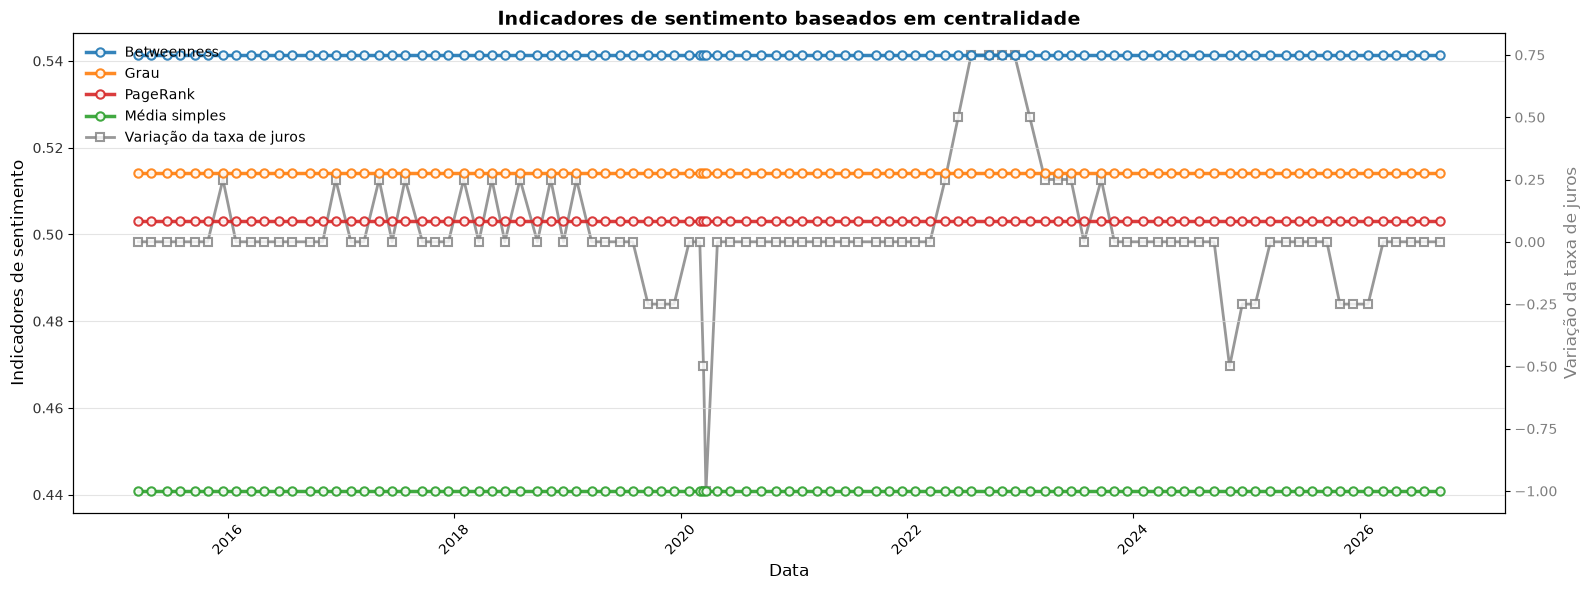

Figure saved to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\TCC_latex\figuras\sentiment_community_by_fomc_period.png


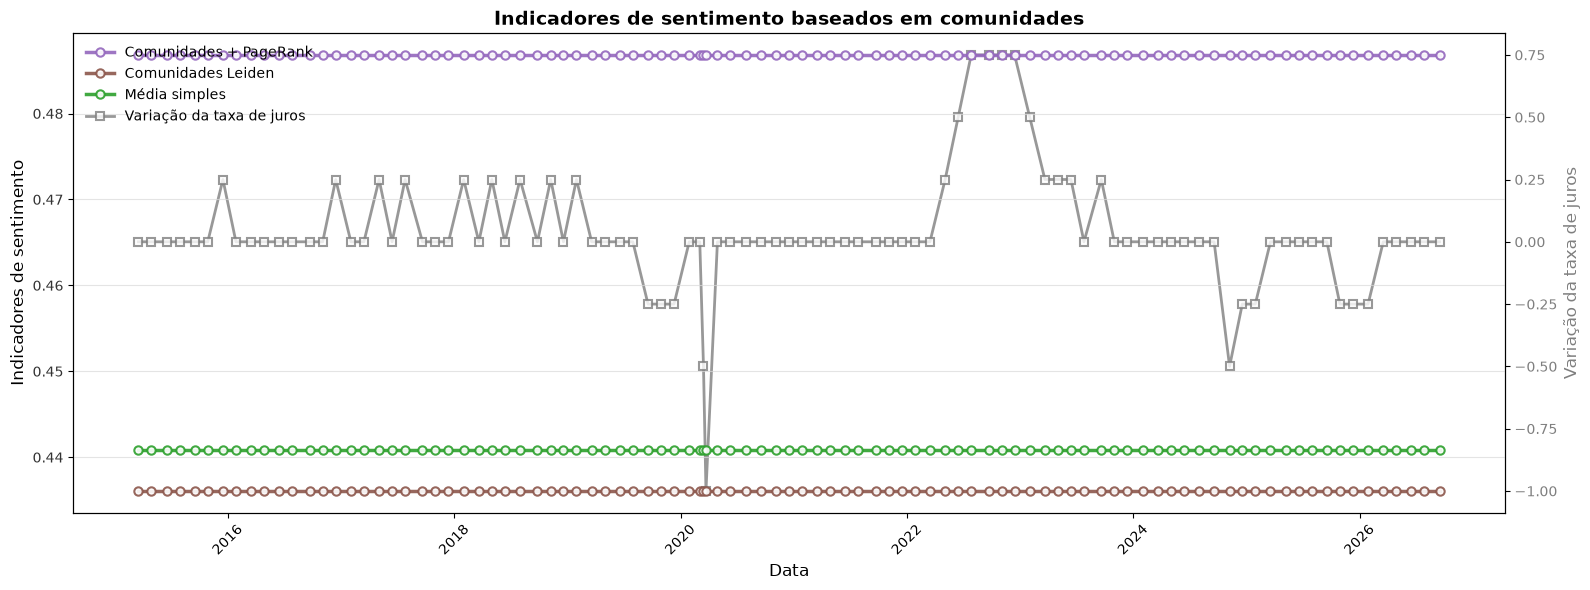

Figure saved to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\TCC_latex\figuras\sentiment_centrality_by_fomc_period_fixed_071.png
Figure saved to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\TCC_latex\figuras\sentiment_community_by_fomc_period_fixed_071.png


In [ ]:
from shutil import copyfile

fixed_scores_for_graphs = pd.read_csv(
    path_data / "period_sentiment_scores_fixed_071.csv",
    parse_dates=["start_date", "end_date"],
)

analyze_sentiment_evolution(
    fixed_scores_for_graphs,
    df_fred_statement_dates,
)

figures_path = path_proj / "TCC_latex" / "figuras"
fixed_graph_names = {
    "sentiment_centrality_by_fomc_period.png": (
        "sentiment_centrality_by_fomc_period_fixed_071.png"
    ),
    "sentiment_community_by_fomc_period.png": (
        "sentiment_community_by_fomc_period_fixed_071.png"
    ),
}

for source_name, fixed_name in fixed_graph_names.items():
    source_path = figures_path / source_name
    fixed_path = figures_path / fixed_name
    copyfile(source_path, fixed_path)
    print(f"Figure saved to {fixed_path}")